## **Exercice 1 : Keras avec implimetation**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Distribution des classes dans l'entraînement :
1    6742
7    6265
3    6131
2    5958
9    5949
0    5923
6    5918
8    5851
4    5842
5    5421
Name: count, dtype: int64


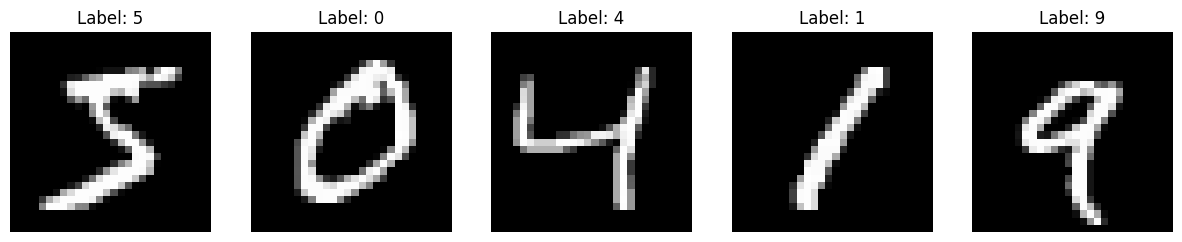

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.datasets import mnist

#les données MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Afficher la forme des données
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
class_counts = pd.Series(y_train).value_counts()
print("Distribution des classes dans l'entraînement :")
print(class_counts)

fig, axes = plt.subplots(1, 5, figsize=(15, 15))
for i in range(5):
    axes[i].imshow(x_train[i], cmap='gray')
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis('off')
plt.show()

# Prétraiter les données :Normaliser:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# Reshaper à ( samples, height , width , channels )
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Convertir les labels en format one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Distribution des classes dans l'entraînement :
1    6742
7    6265
3    6131
2    5958
9    5949
0    5923
6    5918
8    5851
4    5842
5    5421
Name: count, dtype: int64


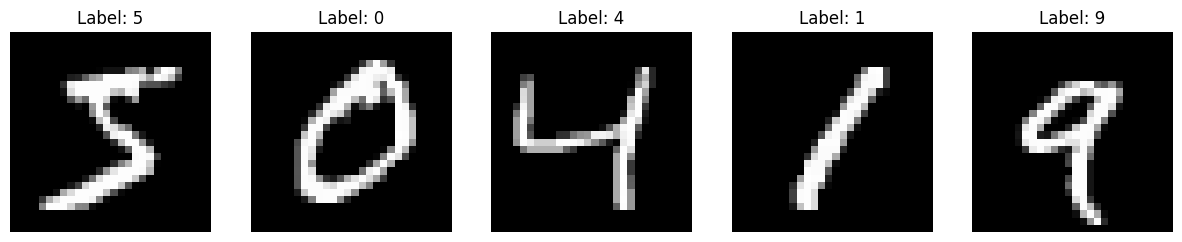

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        57,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,454 (447.09 KB)

 Trainable params: 114,454 (447.09 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Définir l'architecture du modèle CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

# Définir l'architecture du modèle CNN avec des filtres plus petits et du padding "SAME"
model = Sequential()

#Convolution + ReLU avec padding SAME
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)))

#Max-pooling
model.add(MaxPooling2D(pool_size=(2, 2)))


#Convolution + ReLU avec padding SAME
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))

#Max-pooling
model.add(MaxPooling2D(pool_size=(2, 2)))


#Convolution + ReLU avec padding SAME
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))

#Max-pooling
model.add(MaxPooling2D(pool_size=(2, 2)))

#Flatten (pour entrer dans une couche fully-connected)
model.add(Flatten())


#Fully-connected + ReLU
model.add(Dense(100, activation='relu'))

#Fully-connected + Softmax (pour la classification)
model.add(Dense(10, activation='softmax'))

#Résumé du modèle
model.summary()


In [13]:
# Compiler : Adam , crossentropy
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

#Train
history = model.fit(x_train, y_train, epochs=5, batch_size=200, validation_data=(x_test, y_test))

#courbes de précision et de perte
plt.figure(figsize=(12, 6))

# Courbe de précision
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Précision d\'entraînement')
plt.plot(history.history['val_accuracy'], label='Précision de validation')
plt.title('Précision du modèle')
plt.xlabel('Epochs')
plt.ylabel('Précision')
plt.legend()

# Courbe de perte
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Perte d\'entraînement')
plt.plot(history.history['val_loss'], label='Perte de validation')
plt.title('Perte du modèle')
plt.xlabel('Epochs')
plt.ylabel('Perte')
plt.legend()

plt.show()

# Tester le modèle
score = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {score[0]}")
print(f"Test Accuracy: {score[1]}")

Epoch 1/5
 54/300 ━━━━━━━━━━━━━━━━━━━━ 1:01 250ms/step - accuracy: 0.9939 - loss: 0.0154

KeyboardInterrupt: 

Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 82s 269ms/step - accuracy: 0.9870 - loss: 0.0420 - val_accuracy: 0.9887 - val_loss: 0.0341
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 83s 273ms/step - accuracy: 0.9912 - loss: 0.0273 - val_accuracy: 0.9893 - val_loss: 0.0311
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 81s 271ms/step - accuracy: 0.9935 - loss: 0.0211 - val_accuracy: 0.9916 - val_loss: 0.0248
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 84s 279ms/step - accuracy: 0.9949 - loss: 0.0154 - val_accuracy: 0.9892 - val_loss: 0.0314
Epoch 5/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 137s 263ms/step - accuracy: 0.9955 - loss: 0.0141 - val_accuracy: 0.9913 - val_loss: 0.0265


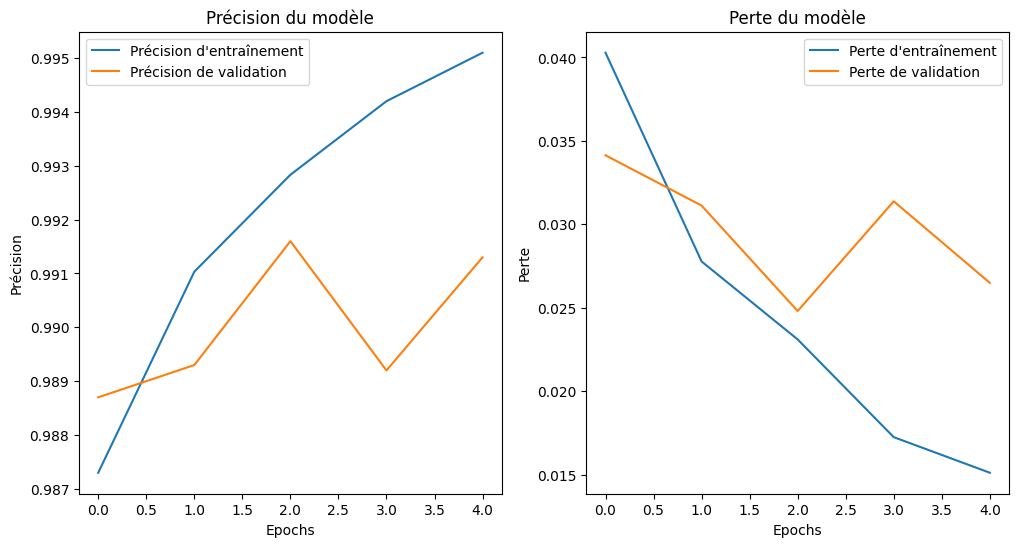

Test Loss: 0.026498598977923393
Test Accuracy: 0.9912999868392944
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


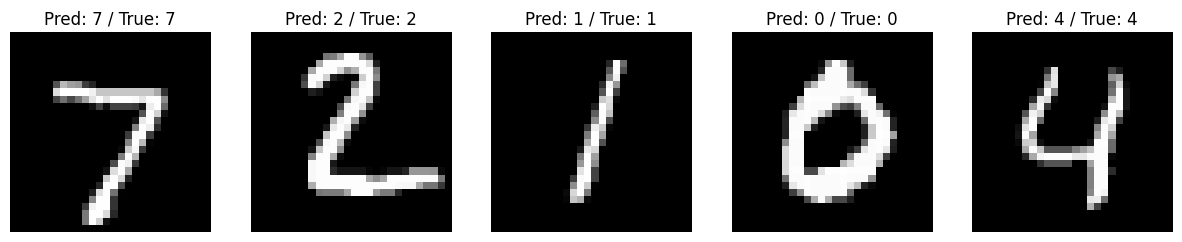

In [12]:
# Prédire les résultats sur les images de test
predictions = model.predict(x_test)

# Afficher quelques prédictions
fig, axes = plt.subplots(1, 5, figsize=(15, 15))
for i in range(5):
    axes[i].imshow(x_test[i], cmap='gray')
    axes[i].set_title(f"Pred: {np.argmax(predictions[i])} / True: {np.argmax(y_test[i])}")
    axes[i].axis('off')
plt.show()


## **Exercice 2 Pytorch:**

In [14]:
pip install torch torchvision

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [16]:
# Définir les transformations : normaliser les images
transform = transforms.Compose([
    transforms.ToTensor(),  # Convertir en Tensor
    transforms.Normalize((0.5,), (0.5,))  # Normalisation avec la moyenne et l'écart-type de 0.5
])

# Télécharger les ensembles pour Train et tes
trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=200, shuffle=True)
testloader = DataLoader(testset, batch_size=200, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 54.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.75MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.13MB/s]


In [17]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Définir les couches
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # convo 32 filtres 3x3
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # convo 64 filtres 3x3
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)  # convo 64 filtres 3x3
        self.pool = nn.MaxPool2d(2, 2)  # Max pooling 2x2

        self.fc1 = nn.Linear(64 * 3 * 3, 100)  # Fully connected, taille d'entrée calculée après pooling
        self.fc2 = nn.Linear(100, 10)  # 10 neurones pour 10 classes

    def forward(self, x):
        # Appliquer les convolutions, activations et pooling
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))

        # aplatissement
        x = x.view(-1, 64 * 3 * 3)

        # 1 ere FC
        x = torch.relu(self.fc1(x))

        # 2 eme FC
        x = self.fc2(x)
        return x


In [18]:
# Initialiser le modèle
model = CNN()

# Définir la fonction de perte et l'optimiseur
criterion = nn.CrossEntropyLoss()  # C'est une classification multi-classe
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [21]:
# Vérifier si un GPU est disponible, sinon utiliser le CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Déplacer le modèle vers le périphérique (GPU ou CPU)
model = model.to(device)

# Fonction d'entraînement (modifiée pour gérer le device)
def train_model(model, trainloader, criterion, optimizer, epochs=10):
    model.train()  # Mettre le modèle en mode entraînement

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in trainloader:
            # Déplacer les données vers le GPU ou CPU
            inputs, labels = inputs.to(device), labels.to(device)

            # Réinitialiser les gradients
            optimizer.zero_grad()

            # Passer les données dans le modèle
            outputs = model(inputs)

            # Calculer la perte
            loss = criterion(outputs, labels)

            # Calculer les gradients et les appliquer
            loss.backward()
            optimizer.step()

            # Statistiques
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(trainloader)}, Accuracy: {100 * correct / total}%")

# Entraîner le modèle sur CPU (ou GPU si disponible)
train_model(model, trainloader, criterion, optimizer, epochs=3)


Epoch 1/3, Loss: 0.033952883744301894, Accuracy: 98.94166666666666%
Epoch 2/3, Loss: 0.029016731832331666, Accuracy: 99.065%
Epoch 3/3, Loss: 0.023424836669582873, Accuracy: 99.23333333333333%


In [23]:
# Fonction de test (modifiée pour gérer le device)
def test_model(model, testloader):
    model.eval()  # Mettre le modèle en mode évaluation
    correct = 0
    total = 0

    with torch.no_grad():  # Désactiver le calcul de gradient pendant le test
        for inputs, labels in testloader:
            # Déplacer les données vers le GPU ou CPU
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total}%")

# Tester le modèle sur CPU (ou GPU si disponible)
test_model(model, testloader)


Test Accuracy: 99.1%


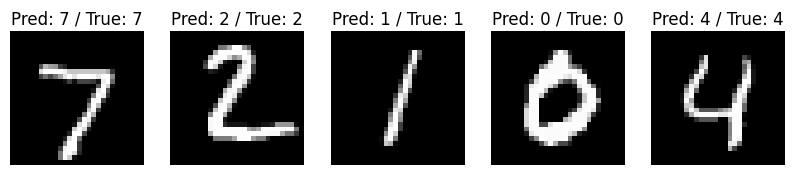

In [25]:
# Visualiser quelques prédictions
def plot_predictions(model, testloader):
    dataiter = iter(testloader)
    images, labels = next(dataiter)  # Utilisez 'next()' de cette manière

    # Déplacer les données vers le périphérique (CPU ou GPU)
    images, labels = images.to(device), labels.to(device)

    # Passer les images à travers le modèle
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    # Afficher les images avec leurs prédictions
    fig, axes = plt.subplots(1, 5, figsize=(10, 5))
    for i in range(5):
        axes[i].imshow(images[i].cpu().numpy().squeeze(), cmap='gray')  # .cpu() pour transférer les données sur le CPU
        axes[i].set_title(f"Pred: {predicted[i].item()} / True: {labels[i].item()}")
        axes[i].axis('off')
    plt.show()

# Visualiser les prédictions
plot_predictions(model, testloader)
